In [ ]:
from importlib.resources import files
import matplotlib.pyplot as plt
from nsbutils.plotting import plot_surf
import numpy as np
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf, fetch_map
from neuromodes.mesh import unmask_data

# Load surface and initialise solver
mesh, medmask = fetch_surf()
solver = EigenSolver(mesh, mask=medmask).solve(200)

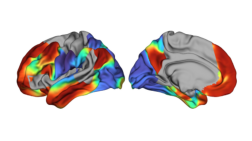

In [ ]:
map = fetch_map('fcgradient1')[medmask]

# Add nans in to see how reconstruct() handles them
map_nanful = map.copy()
map_nanful[:10000] = np.nan

# plot original map
lh_surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'

data = unmask_data(map_nanful, medmask) # Original map

plot_surf(lh_surfpath, data)

### Compare project vs regress beta values

In [3]:
from neuromodes.basis import decompose

mode_counts = [10, 20, 50, 100, 200]#, 500, 1000]

beta_proj_nanful = decompose(
    emodes=solver.emodes,
    data=map_nanful,
    mass=solver.mass,
    method='project'
)[:, 0]

beta_regress_nanful = []
for i, mode_count in enumerate(mode_counts):
    beta_regress_nanful.append(decompose(
        emodes=solver.emodes[:, :mode_count],
        data=map_nanful,
        method='regress'
    )[:, 0])

c:\Users\ipop0003\neuromodes\neuromodes\basis.py:109: UserWarning: data contains NaNs and/or Infs; these will be disregarded during decomposition by masking corresponding vertices from data and emodes.
  warn(nan_warning)


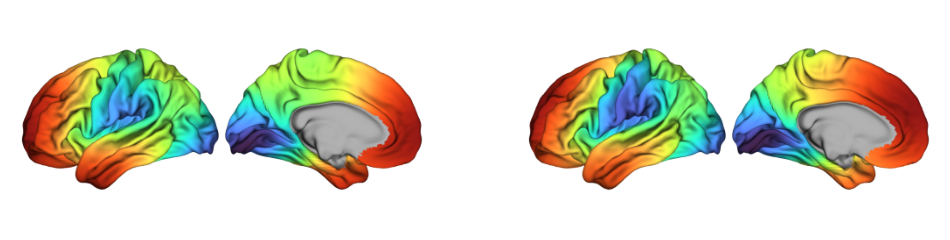

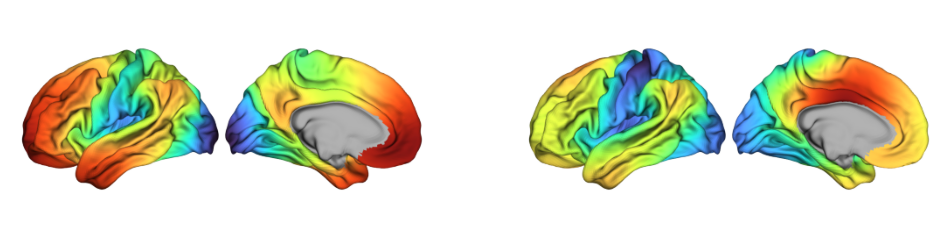

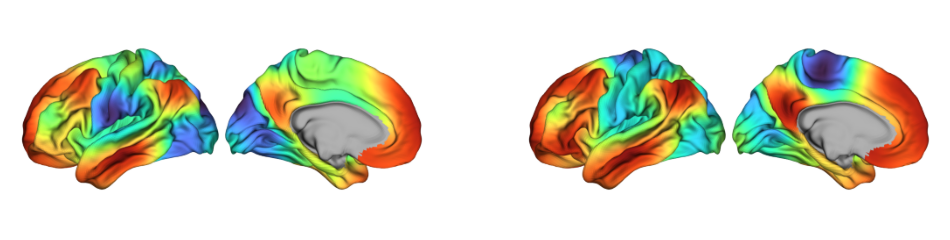

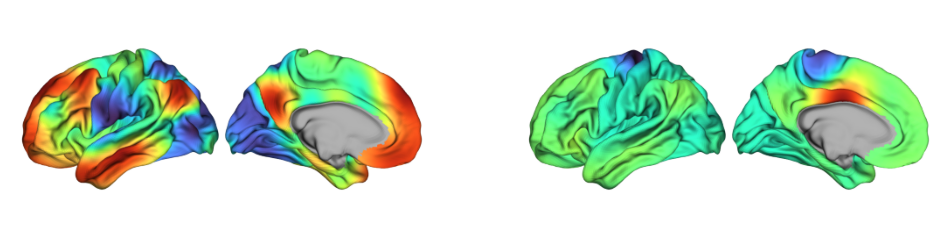

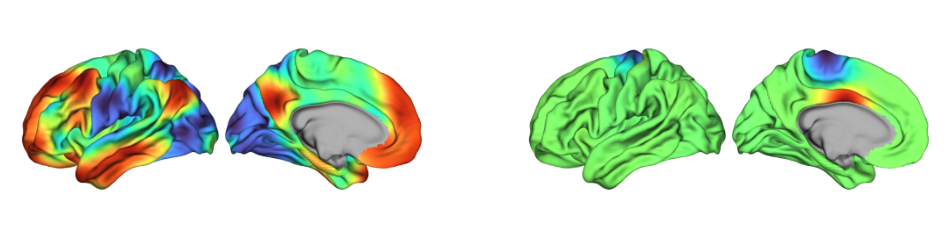

In [4]:
# Plot recons on surface for visual comparison
for i, mode_count in enumerate(mode_counts):
    recon_proj = solver.emodes[:, :mode_count] @ beta_proj_nanful[:mode_count]
    recon_regress = solver.emodes[:, :mode_count] @ beta_regress_nanful[i][:mode_count]

    recon_proj = unmask_data(recon_proj, medmask)
    recon_regress = unmask_data(recon_regress, medmask)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    plot_surf(lh_surfpath, recon_proj, ax=axes[0])
    plot_surf(lh_surfpath, recon_regress, ax=axes[1])
    plt.show()

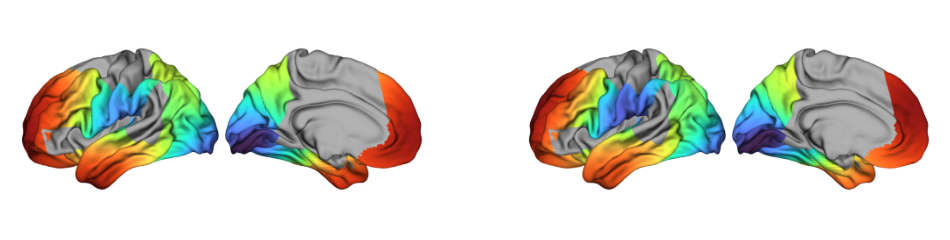

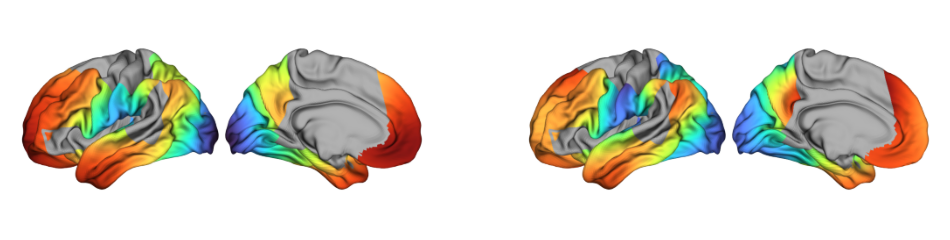

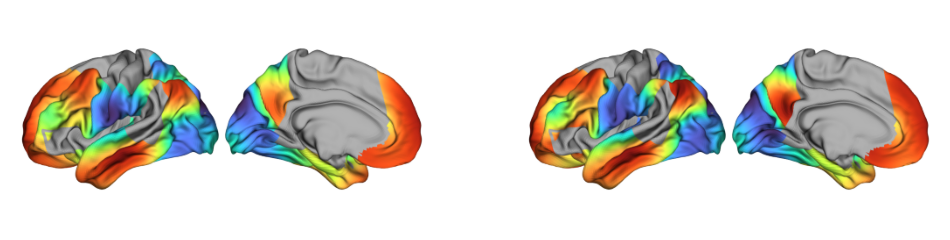

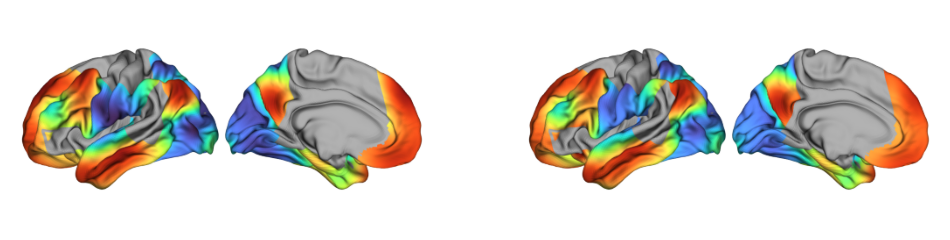

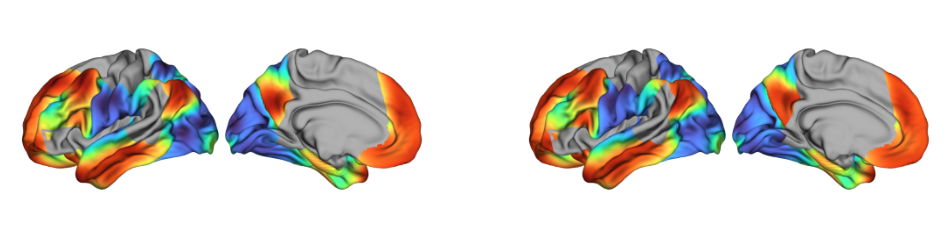

In [ ]:
# Above plot but mask nans for comparable colour range

for i, mode_count in enumerate(mode_counts):
    recon_proj = solver.emodes[:, :mode_count] @ beta_proj_nanful[:mode_count]
    recon_regress = solver.emodes[:, :mode_count] @ beta_regress_nanful[i][:mode_count]

    recon_proj[:10000] = np.nan
    recon_regress[:10000] = np.nan

    recon_proj = unmask_data(recon_proj, medmask)
    recon_regress = unmask_data(recon_regress, medmask)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    plot_surf(lh_surfpath, recon_proj, ax=axes[0])
    plot_surf(lh_surfpath, recon_regress, ax=axes[1])
    plt.show()

In [6]:
# Get coefficients without NaNs for comparison
beta_proj = decompose(
    emodes=solver.emodes,
    data=map,
    mass=solver.mass,
    method='project'
)[:, 0]

beta_regress = []
for i, mode_count in enumerate(mode_counts):
    beta_regress.append(decompose(
        emodes=solver.emodes[:, :mode_count],
        data=map,
        method='regress'
    )[:, 0])

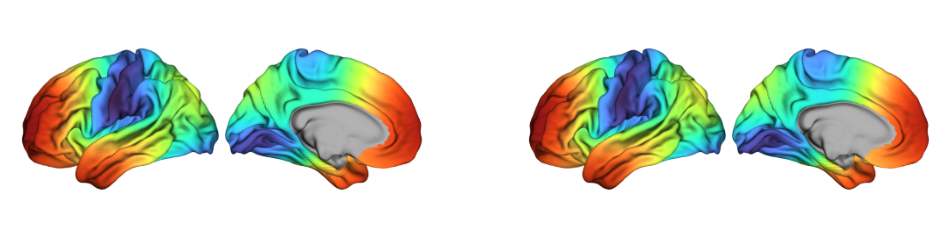

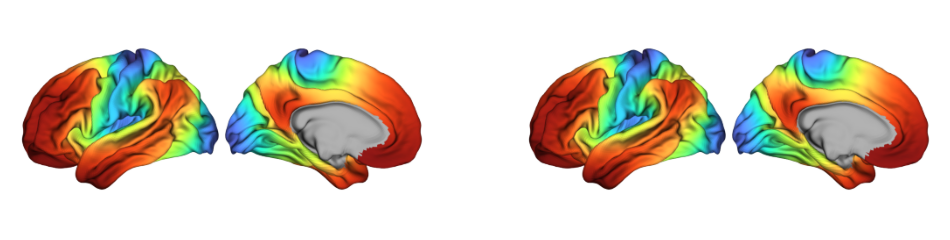

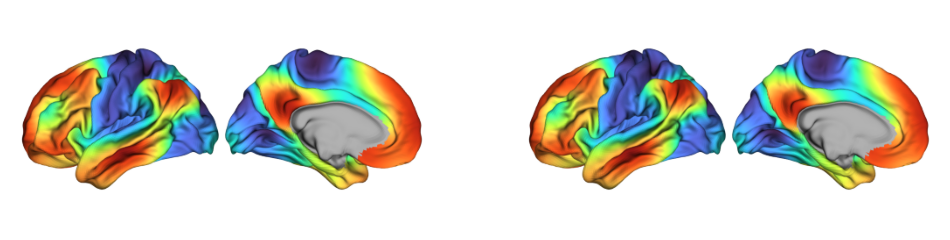

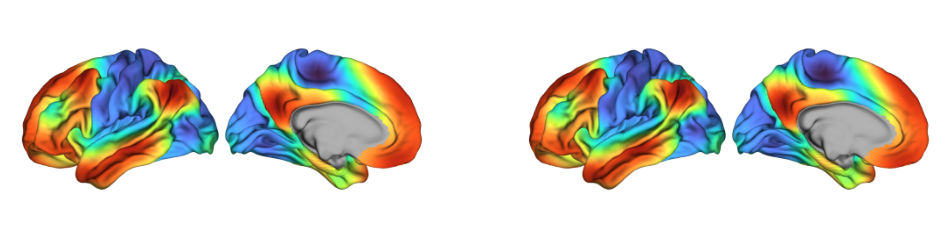

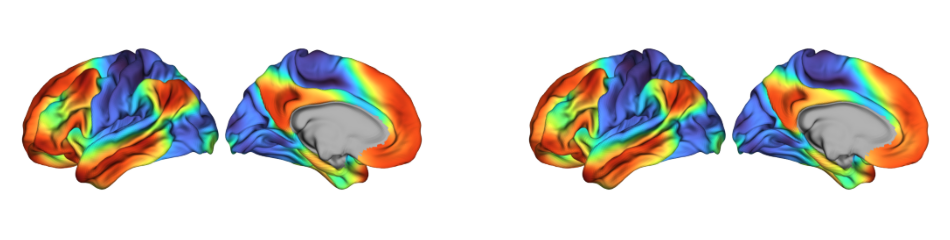

In [ ]:
# Plot
for i, mode_count in enumerate(mode_counts):
    recon_proj = solver.emodes[:, :mode_count] @ beta_proj[:mode_count]
    recon_regress = solver.emodes[:, :mode_count] @ beta_regress[i][:mode_count]

    recon_proj = unmask_data(recon_proj, medmask)
    recon_regress = unmask_data(recon_regress, medmask)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    plot_surf(lh_surfpath, recon_proj, ax=axes[0])
    plot_surf(lh_surfpath, recon_regress, ax=axes[1])
    plt.show()

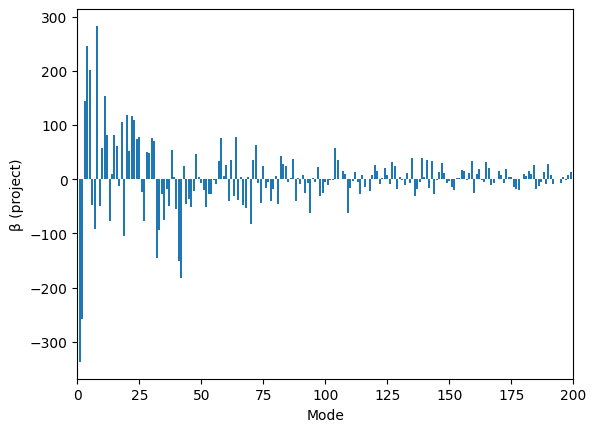

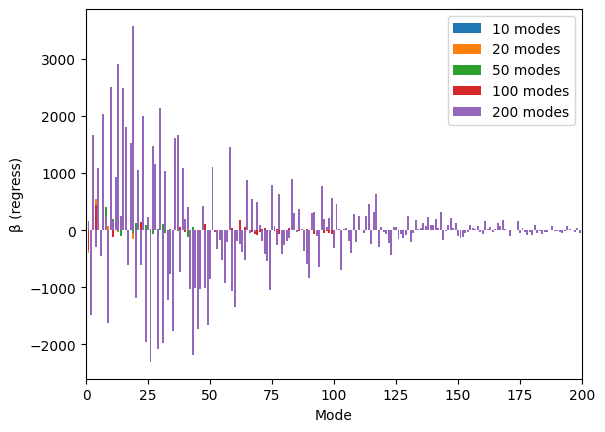

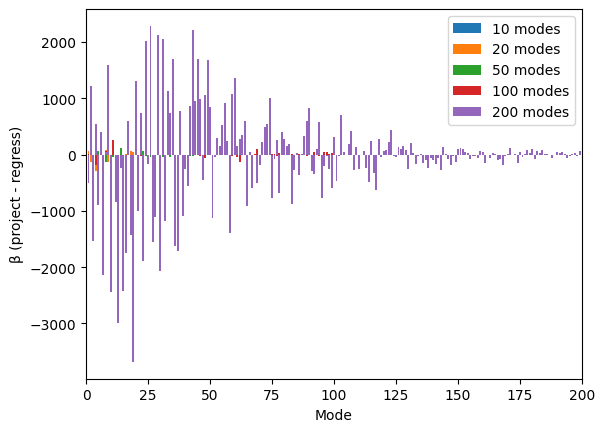

In [9]:
# Plot beta weights for project
plt.bar(range(beta_proj_nanful.shape[0]), beta_proj_nanful)
plt.xlabel('Mode')
plt.xlim(0, solver.n_modes)
plt.ylabel('β (project)')
plt.show()

# Plot beta weights for each mode count for regress all on same plot
for i, mode_count in enumerate(mode_counts):
    plt.bar(range(mode_count), beta_regress_nanful[i][:mode_count], label=f'{mode_count} modes')
plt.xlabel('Mode')
plt.xlim(0, solver.n_modes)
plt.ylabel('β (regress)')
plt.legend()
plt.show()

# Plot difference between project and regress for each mode count
for i, mode_count in enumerate(mode_counts):
    plt.bar(range(mode_count), beta_proj_nanful[:mode_count] - beta_regress_nanful[i][:mode_count], label=f'{mode_count} modes')
plt.xlabel('Mode')
plt.xlim(0, solver.n_modes)
plt.ylabel('β (project - regress)')
plt.legend()
plt.show()

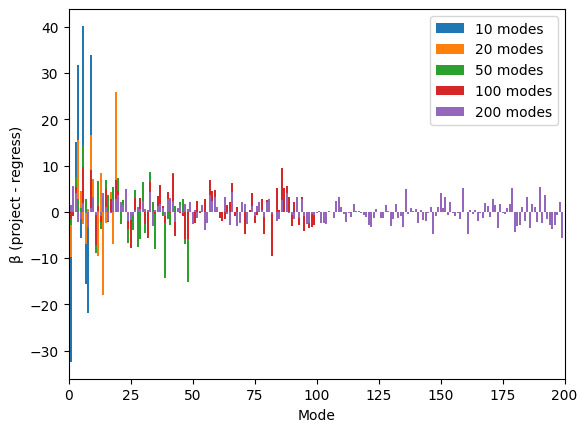

In [ ]:
# Above plot but from nanless data
for i, mode_count in enumerate(mode_counts):
    plt.bar(range(mode_count), beta_proj[:mode_count] - beta_regress[i][:mode_count], label=f'{mode_count} modes')
plt.xlabel('Mode')
plt.xlim(0, solver.n_modes)
plt.ylabel('β (project - regress)')
plt.legend()
plt.show()